In [8]:
from urllib.request import urlopen
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import defaultdict

## Function that allows us to automate calls to the API so that we can extract data fro Large Data Sets ##


In [4]:
def get_blast_info(sn_name):
    """
    Fetch information for a supernova/transient from the BLAST API.

    Parameters
    ----------
    sn_name : str
        The supernova/transient name (e.g. "2004ef").

    Returns
    -------
    tuple
        (row_dict, missing_name_or_None)
        - On success: (dict of BLAST fields, None)
        - On failure: ({}, sn_name)
    """

    url = f"https://blast.ncsa.illinois.edu/api/transient/get/{sn_name}?format=json"
    try:
        with urlopen(url) as r:
            payload = json.loads(r.read())
    
    ## The following catches any Python Exception that happened within the "try" block.
    ## Error object gets stored as the variable e.
    ## Also keeps track of missing supernova names. Upon exceptions being thrown, ends up returning just
    ## the string that is the SNIa name. 
    except Exception as e:
        print(f"Error fetching {sn_name}: {e}")
        return {}, sn_name

    row = {
        "blast_transient_spectroscopic_class": (payload.get("transient_spectroscopic_class") or "").strip(),
        "blast_transient_photometric_class": (payload.get("transient_photometric_class") or "").strip(),
        
        "blast_host_name": payload.get("host_name"),
        "blast_host_ra_deg": payload.get("host_ra_deg"),
        "blast_host_dec_deg": payload.get("host_dec_deg"),
        "blast_host_redshift": payload.get("host_redshift"),
        "blast_host_EBV_MW": payload.get("host_milkyway_dust_reddening"),

        # Local SED
        "blast_local_log_mass_50": payload.get("local_aperture_host_log_mass_50"),
        "blast_local_log_sfr_50": payload.get("local_aperture_host_log_sfr_50"),
        "blast_local_log_ssfr_50": payload.get("local_aperture_host_log_ssfr_50"),
        "blast_local_log_age_50": payload.get("local_aperture_host_log_age_50"),
        "blast_local_mass_surviving_ratio": payload.get("local_aperture_host_mass_surviving_ratio"),

        # Global SED
        "blast_global_log_mass_50": payload.get("global_aperture_host_log_mass_50"),
        "blast_global_log_sfr_50": payload.get("global_aperture_host_log_sfr_50"),
        "blast_global_log_ssfr_50": payload.get("global_aperture_host_log_ssfr_50"),
        "blast_global_log_age_50": payload.get("global_aperture_host_log_age_50"),
        "blast_global_mass_surviving_ratio": payload.get("global_aperture_host_mass_surviving_ratio"),
    }
    return row, None

## Querying the DES Catalog ##

One of the biggest issues here is 

In [ ]:
# Load your CSV 
csv_path = "data/des_smaple_SNIa.csv"
df = pd.read_csv(csv_path)

# Collect BLAST info
blast_rows = []
missing_from_blast = []

# Can replace df["CID"] with whatever name df
# has for the IAUA name 
for sn in df["CID"]:
    row, missing = get_blast_info(str(sn))  # ensure string format
    blast_rows.append(row)
    if missing:   # missing is sn_name or None
        missing_from_blast.append(missing)

# Merge results back into DataFrame
blast_df = pd.DataFrame(blast_rows)
df = pd.concat([df, blast_df], axis=1)

# Save to new file
df.to_csv("data/DES_BLAST.csv", index=False)

print("Failed lookups:", missing_from_blast)

Error fetching 2001ah: HTTP Error 404: Not Found
Error fetching 2001ay: HTTP Error 404: Not Found
Error fetching 2001eh: HTTP Error 404: Not Found
Error fetching 2002he: HTTP Error 404: Not Found
Error fetching 2002hu: HTTP Error 404: Not Found
Error fetching 2003fa: HTTP Error 404: Not Found
Error fetching 2003iv: HTTP Error 404: Not Found
Error fetching 2005ms: HTTP Error 404: Not Found
Error fetching 2006S: HTTP Error 404: Not Found
Error fetching 2006az: HTTP Error 404: Not Found
Error fetching 2006cf: HTTP Error 404: Not Found
Error fetching 2006oa: HTTP Error 404: Not Found
Error fetching 2006on: HTTP Error 404: Not Found
Error fetching 2006qo: HTTP Error 404: Not Found
Error fetching 2007R: HTTP Error 404: Not Found
Error fetching 2007sw: HTTP Error 404: Not Found
Error fetching 2008050: HTTP Error 404: Not Found
Error fetching 2008051: HTTP Error 404: Not Found
Error fetching 2010dt: HTTP Error 404: Not Found
Error fetching AT2016ews: HTTP Error 404: Not Found
Error fetching AT

Now we will perform a quick sort that filters the .csv and splits it into what were were able to query from BLAST vs. what were wer not able to query from BLAST. 

In [3]:
csv_in  = "data/DES_BLAST.csv"
csv_out = "data/DES_BLAST_results.csv"
csv_missing = "data/DES_BLAST_missing.csv"

# Load
df = pd.read_csv(csv_in)

# All BLAST columns (those we added with the 'blast_' prefix)
blast_cols = [c for c in df.columns if c.startswith("blast_")]

# Mark rows that have at least ONE non-null BLAST value
has_blast = df[blast_cols].notna().any(axis=1)

# Keep only rows with BLAST info
kept = df[has_blast].copy()

# Rows removed = missing from BLAST entirely
missing = df[~has_blast].copy()

# (Optional) pick a likely name/ID column to show in the missing file
name_col = next((c for c in ["CID", "SNID", "transient_name"] if c in df.columns), None)
if name_col:
    missing = missing[[name_col] + blast_cols]  # show identifier + the empty blast columns

# Save results
kept.to_csv(csv_out, index=False)
missing.to_csv(csv_missing, index=False)

print(f"Kept {len(kept)} rows with BLAST data → {csv_out}")
print(f"Removed {len(missing)} rows missing BLAST data → {csv_missing}")

Kept 161 rows with BLAST data → data/DES_BLAST_results.csv
Removed 34 rows missing BLAST data → data/DES_BLAST_missing.csv


1829 DES-SN5YR SNe Ia total


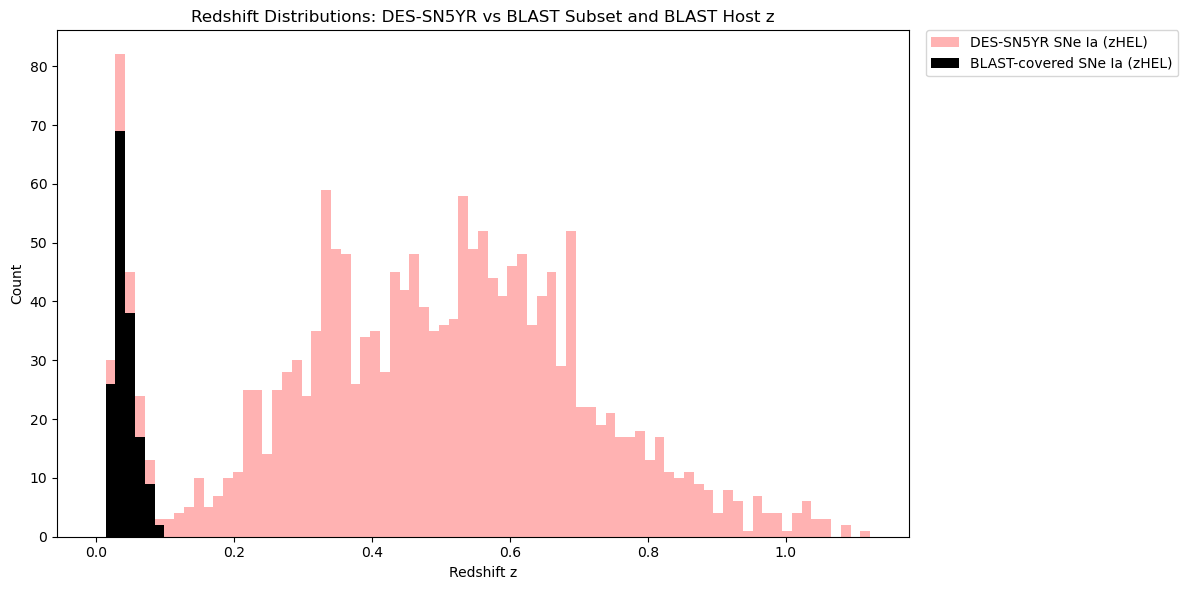

In [21]:
DES_SN_CSV = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data/DES-SN5YR_HD+MetaData.csv"
BLAST_CSV  = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/explore_webapi_with_blast_only.csv"

# Load
des_sn   = pd.read_csv(DES_SN_CSV)
blast_df = pd.read_csv(BLAST_CSV)

print(len(des_sn), "DES-SN5YR SNe Ia total")

z_all_des      = pd.to_numeric(des_sn["zHEL"], errors="coerce").dropna().to_numpy()
z_blast_subset = pd.to_numeric(blast_df["zHEL"], errors="coerce").dropna().to_numpy()
z_blast_host   = pd.to_numeric(blast_df["blast_host_redshift"], errors="coerce").dropna().to_numpy()

# Shared binning — one line!
zmin, zmax = min(z_all_des.min(), z_blast_subset.min(), z_blast_host.min()), \
             max(z_all_des.max(), z_blast_subset.max(), z_blast_host.max())
bins = np.linspace(zmin, zmax, 80)   # <-- control bins right here

plt.figure(figsize=(12, 6))
plt.hist(z_all_des,      bins=bins, alpha=0.3, label="DES-SN5YR SNe Ia (zHEL)", color = "red")
plt.hist(z_blast_subset, bins=bins, alpha=1, label="BLAST-covered SNe Ia (zHEL)", color = "black")

plt.xlabel("Redshift z")
plt.ylabel("Count")
plt.title("Redshift Distributions: DES-SN5YR vs BLAST Subset and BLAST Host z")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

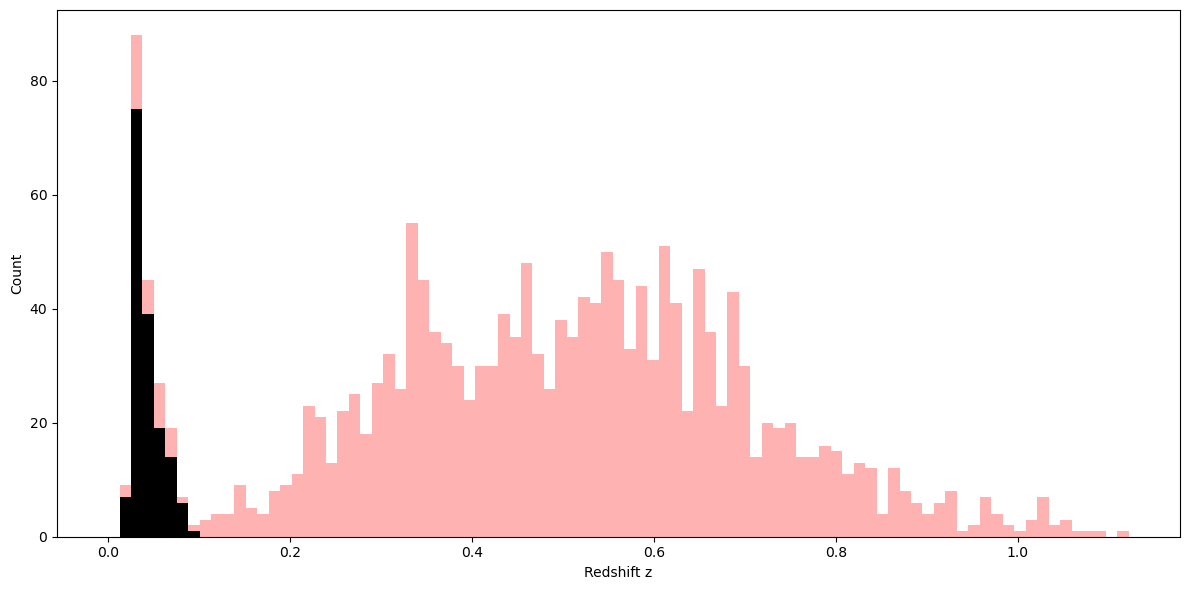

In [20]:
DES_SN_CSV = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data/DES-SN5YR_HD+MetaData.csv"
BLAST_CSV  = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/explore_webapi_with_blast_only.csv"

# Load
des_sn   = pd.read_csv(DES_SN_CSV)
blast_df = pd.read_csv(BLAST_CSV)

z_all_des      = pd.to_numeric(des_sn["zHEL"], errors="coerce").dropna().to_numpy()
z_blast_subset = pd.to_numeric(blast_df["zHEL"], errors="coerce").dropna().to_numpy()
z_blast_host   = pd.to_numeric(blast_df["blast_host_redshift"], errors="coerce").dropna().to_numpy()

# Shared binning — one line!
zmin, zmax = min(z_all_des.min(), z_blast_subset.min(), z_blast_host.min()), \
             max(z_all_des.max(), z_blast_subset.max(), z_blast_host.max())
bins = np.linspace(zmin, zmax, 90)   # <-- control bins right here

plt.figure(figsize=(12, 6))
plt.hist(z_all_des,      bins=bins, alpha=0.3, label="DES-SN5YR SNe Ia (zHEL)", color = "red")
plt.hist(z_blast_subset, bins=bins, alpha=1, label="BLAST-covered SNe Ia (zHEL)", color = "black")

plt.xlabel("Redshift z")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

TRIED USING THIS LINK BUT SOME THINGS ARE VERY BROKEN:


https://www.wis-tns.org/content/tns-getting-started#:~:text=performing%20time,reducing%20the%20load%20on%20the


Daily CSV Staging

Every day after UT midnight, two CSV files are created and are accessible for
download under: https://www.wis-tns.org/system/files/tns_public_objects/

1. tns_public_objects.csv.zip - holds the entire catalog of TNS public objects
(AT/SN/FRB/... ~160K as of Jan 2025). This file is overwritten daily. The date and
time when the list of objects was created is specified in the first line; e.g.
"2025-01-15 00:00:00"

2. tns_public_objects_YYYYMMDD.csv.zip - holds only those entries (objects) that
were either added or modified during the specified day. So, e.g. during Jan 15,
2025 it is possible to download this latest CSV for the previous day:
tns_public_objects_20250114.csv.zip The first line in the CSV will contain the
exact duration covering the entries in the file; e.g. for the above example:
"2025-01-14 00:00:00 - 23:59:59"

The separate daily files remain in place for 2 weeks backwards.

In addition to the above csv's of the full list of the public TNS objects and
the "daily deltas", there are also "hourly delta" csv files, which are created on
the hour and list the new public objects (or those for which e.g. the object
type/redshift/coords were modified) from the passing hour. Those are of format
tns_public_objects_HH.csv.zip, e.g. tns_public_objects_09.csv.zip (containing
the new/updated entries between 8:00-9:00 UT in this example), which overwrite
each other on a 24 hr cycle.

Staging the CSV files serves to fulfil requests by TNS users, as well as encourage
performing time-consuming operations locally by users, reducing the load on the
TNS servers.

For example, if you need to cross-match entire catalogs or long object lists, we
request that this would be done locally, against the csv (or a locally managed
DB), rather than by executing multiple cone-searches via the Search API. Calling
the APIs for a limited number of objects is clearly fine, but we ask that our
users apply appropriate caution and sensibility when using the TNS resources,
that serve a broad community.


The csv's contain the following columns, as displayed on the 2nd header line in all csv files:

"objid","name_prefix","name","ra","declination","redshift","typeid","type", 
"reporting_groupid","reporting_group","source_groupid","source_group", 
"discoverydate","discoverymag","discmagfilter","filter",
"reporters","time_received","internal_names",
"Discovery_ADS_bibcode","Class_ADS_bibcodes","creationdate","lastmodified"
 

It is possible to download the csv's either by using curl/wget etc.., providing
a bot's tns_marker and API-key, or either a user's tns_marker; e.g.:

curl -X POST -H 'user-agent: tns_marker{"tns_id":YOUR_BOT_ID, "type": "bot",  "name":"YOUR_BOT_NAME"}' -d 'api_key=YOUR-API-KEY' https://www.wis-tns.org/system/files/tns_public_objects/tns_public_obje… > tns_public_objects.csv.zip 
 

curl -X POST -H 'user-agent: tns_marker{"tns_id":YOUR_BOT_ID, "type": "bot",  "name":"YOUR_BOT_NAME"}' -d 'api_key=YOUR-API-KEY' https://www.wis-tns.org/system/files/tns_public_objects/tns_public_obje… > tns_public_objects_20250114.csv.zip
 

curl -X POST -H 'user-agent: tns_marker{"tns_id":YOUR_USER_ID,"type": "user", "name":"YOUR_USERNAME"}' https://www.wis-tns.org/system/files/tns_public_objects/tns_public_obje… > tns_public_objects_09.csv.zip

Or if being logged in, you can just go to the URL for downloading the CSV:

https://www.wis-tns.org/system/files/tns_public_objects/tns_public_obje…
https://www.wis-tns.org/system/files/tns_public_objects/tns_public_obje… (specify the required date)

You may refer to the following Newsfeeds that relate to the staging of the TNS public objects csv files:
 

Addition of "hourly delta" csv's staging the TNS public objects
Daily staging of all TNS public objects as CSV text files
 

A clarification:

The full csv includes all objects that were reported to the TNS, so NOT including the past ("historic") SNe.
The past SNe can be downloaded using this search query: https://www.wis-tns.org/search?&isTNS_AT=no



In [9]:

# load your csvs
des = pd.read_csv("data/DES_BLAST_missing.csv")         # has column "CID"
tns = pd.read_csv("data/TNS_public_objects.csv", skiprows=1)

# normalize to strings
des["CID"] = des["CID"].astype(str).str.upper().str.strip()
tns["name"] = tns["name"].astype(str).str.upper().str.strip()

matches = []
for cid in des["CID"]:
    hit = tns[tns["name"].str.contains(cid, na=False)]
    if not hit.empty:
        for _, row in hit.iterrows():
            matches.append({"CID": cid, "TNS_NAME": row["name"]})

# results in a DataFrame
matches_df = pd.DataFrame(matches)
print(matches_df)

# optional: save to file
matches_df.to_csv("data/DES_TNS_missing_name_matches.csv", index=False)

   CID TNS_NAME
0  NAN  2025NAN
1  NAN  2024NAN
2  NAN  2023NAN
3  NAN  2022NAN
4  NAN  2021NAN
5  NAN  2020NAN
6  NAN  2019NAN


In [6]:
tns = pd.read_csv("data/TNS_public_objects.csv", skiprows=1)
print(tns.columns.tolist())

['objid', 'name_prefix', 'name', 'ra', 'declination', 'redshift', 'typeid', 'type', 'reporting_groupid', 'reporting_group', 'source_groupid', 'source_group', 'discoverydate', 'discoverymag', 'discmagfilter', 'filter', 'reporters', 'time_received', 'internal_names', 'Discovery_ADS_bibcode', 'Class_ADS_bibcodes', 'creationdate', 'lastmodified']
